# Support Resistance

In [ ]:
import pandas as pd

prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T

    dates = pd.to_datetime(df.index.tolist()).tolist()

    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", "").lower() for c in cols]
    df.columns = cols
    return df, dates, cols


df, dates, cols = load_data(stock_code)


from utils.support_resistance import detect_support_resistance, plot_support_resistance


def support_resistance_analysis(lot=0, lot_size=200, log=0):
    n = len(df)

    start_date_ind = n - lot_size * (lot + 1)
    end_date_ind = n - lot_size * lot - 1

    start_date = dates[start_date_ind]
    end_date = dates[end_date_ind]

    print(start_date, end_date)

    _df = df[start_date:end_date]

    if log:
        print(start_date, end_date)
        print(_df)

    if _df.empty:
        print("⚠️ Empty dataframe. Check date slicing.")
        print(start_date, end_date)
        raise ValueError("Data slice is empty")

    support, resistance, _df = detect_support_resistance(_df)
    _support, _resistance = [], []
    for price, strength in support:
        _support.append((price, strength, 0))
    for price, strength in resistance:
        _resistance.append((price, strength, 0))
    fig = plot_support_resistance(_df, _support, _resistance)
    return support, resistance, _df

2025-02-10 00:00:00 2025-09-18 00:00:00


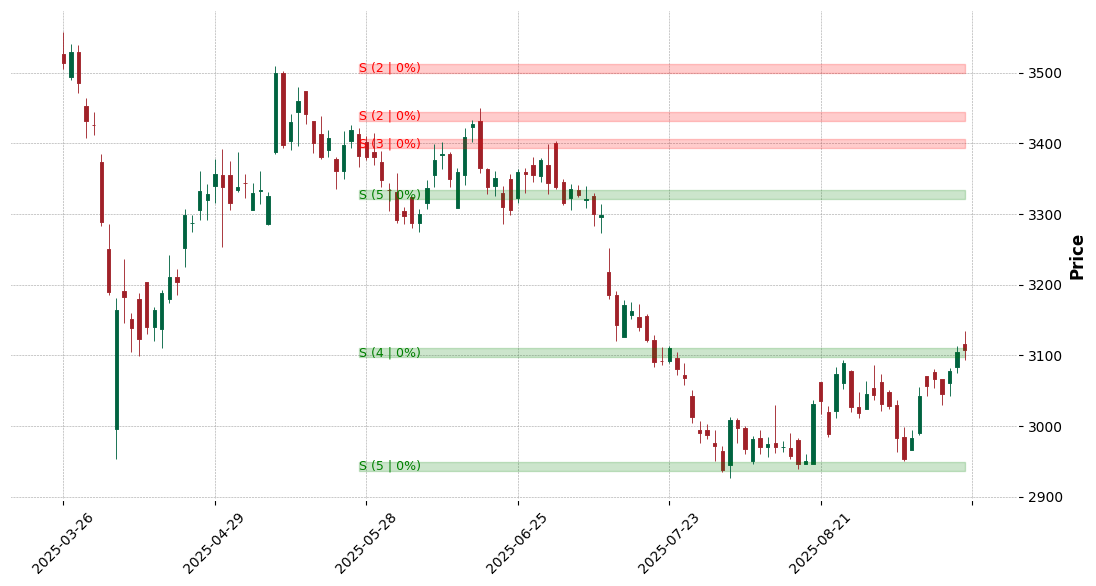

In [2]:
lot = 1
lot_size = 150
support, resistance, _df = support_resistance_analysis(lot, lot_size)

### Claude Function

In [1]:
import pandas as pd

prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T

    dates = pd.to_datetime(df.index.tolist()).tolist()

    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", "").lower() for c in cols]
    df.columns = cols
    return df, dates, cols


df, dates, cols = load_data(stock_code)


from utils.support_resistance import (
    detect_support_resistance_claude,
    plot_support_resistance,
    detect_support_resistance_walkforward,
    detect_support_resistance_walkforward_optimized,
    plot_support_resistance_compact,
    plot_support_resistance_enhanced,
)
from utils.candles import detect_candles_claude, plot_valid_signals


def support_resistance_analysis_claude(df, lot=0, lot_size=200, log=0):
    n = len(df)

    start_date_ind = n - lot_size * (lot + 1)
    end_date_ind = n - lot_size * lot - 1

    start_date = dates[start_date_ind]
    end_date = dates[end_date_ind]

    print(start_date, end_date)

    _df = df[start_date:end_date]

    if log:
        print(start_date, end_date)
        print(_df)

    if _df.empty:
        print("⚠️ Empty dataframe. Check date slicing.")
        print(start_date, end_date)
        raise ValueError("Data slice is empty")

    support, resistance, _df = detect_support_resistance_walkforward(_df)
    # fig = plot_support_resistance(_df, support, resistance)
    return _df, support, resistance

In [2]:
def candle_stick_analysis_claude(df, lot=0, lot_size=200, log=0):
    n = len(df)

    start_date_ind = n - lot_size * (lot + 1)
    end_date_ind = n - lot_size * lot - 1

    print(start_date_ind, end_date_ind)
    start_date = dates[start_date_ind]
    end_date = dates[end_date_ind]

    _df = df[start_date:end_date]

    if log:
        print(start_date, end_date)
        print(_df)

    if _df.empty:
        print("⚠️ Empty dataframe. Check date slicing.")
        print(start_date, end_date)
        raise ValueError("Data slice is empty")

    candle_df = detect_candles_claude(_df)
    # fig = plot_support_resistance(_df, support, resistance)
    return candle_df

In [3]:
lot = 1
lot_size = 150
_df, support, resistance = support_resistance_analysis_claude(df, lot, lot_size)
candle_df = candle_stick_analysis_claude(df, lot, lot_size)

2025-02-10 00:00:00 2025-09-18 00:00:00
5586 5735


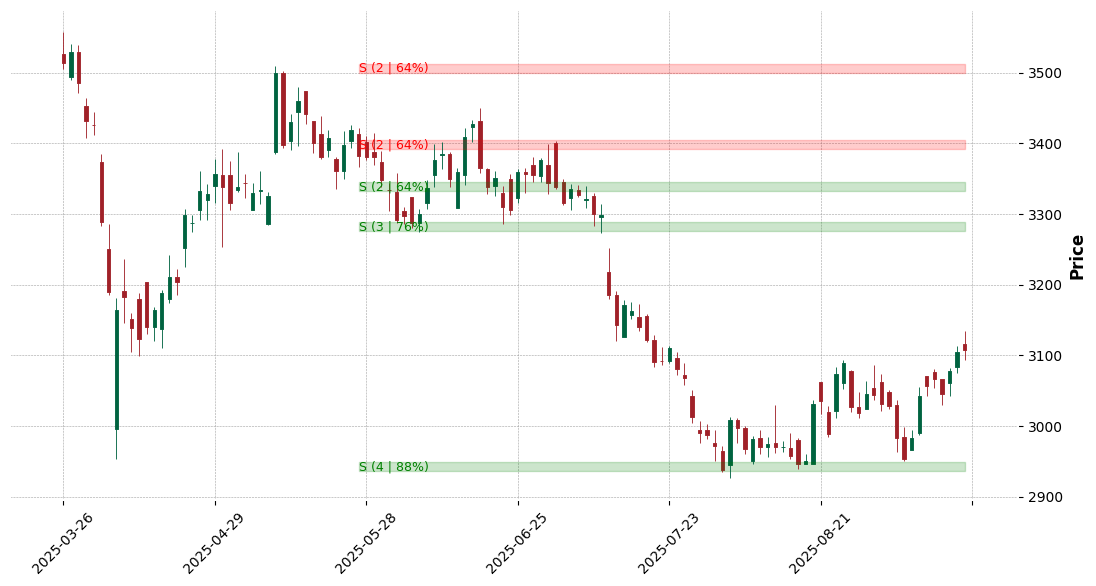

In [4]:
_fig, _axlist = plot_support_resistance(_df, support, resistance)

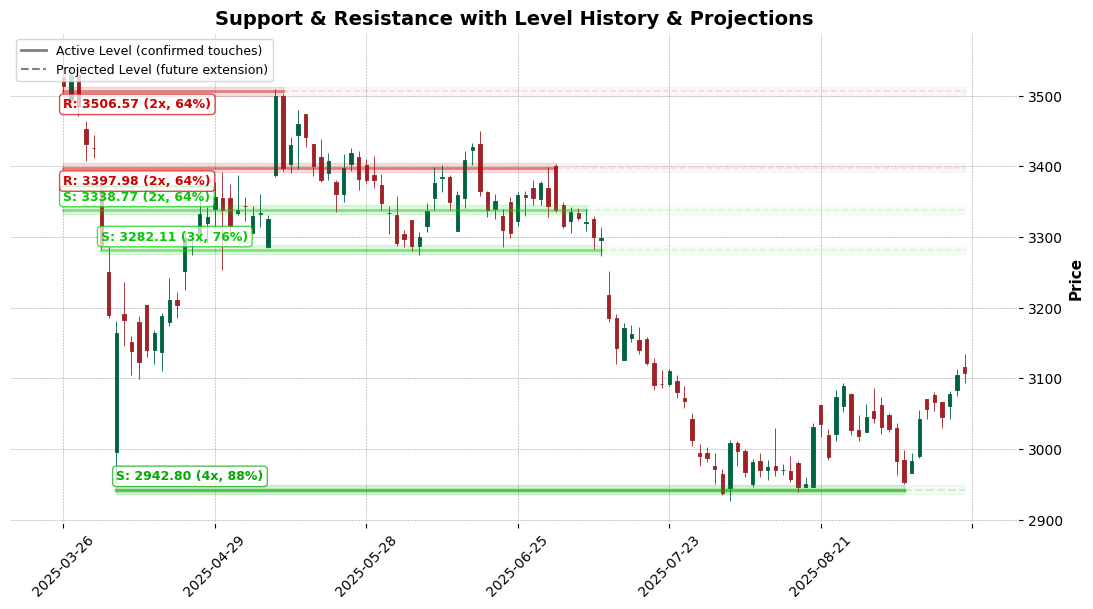

In [5]:
_fig, _axlist = plot_support_resistance_enhanced(_df, support, resistance)

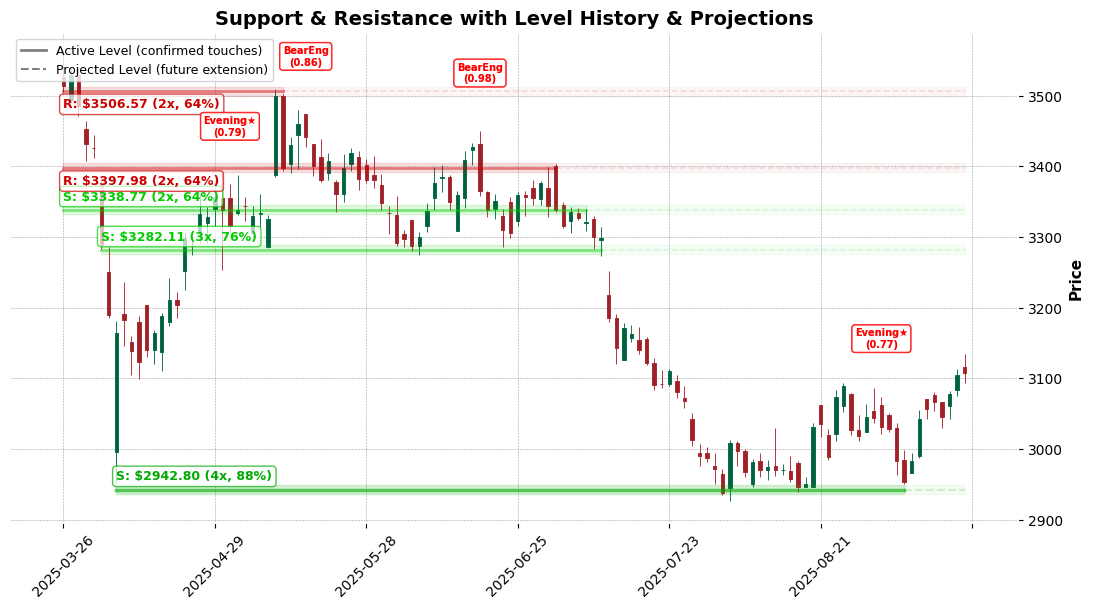

In [16]:
fig, axlist = plot_valid_signals(
    candle_df, conf_threshold=0.5, fig=_fig, axlist=_axlist
)

fig

In [ ]:
support

In [ ]:
_df[-60:].drop(['high', 'low', 'open', 'volume', 'near_support', 'near_resistance', 'support_zone_count', 'resistance_zone_count'], axis=1)

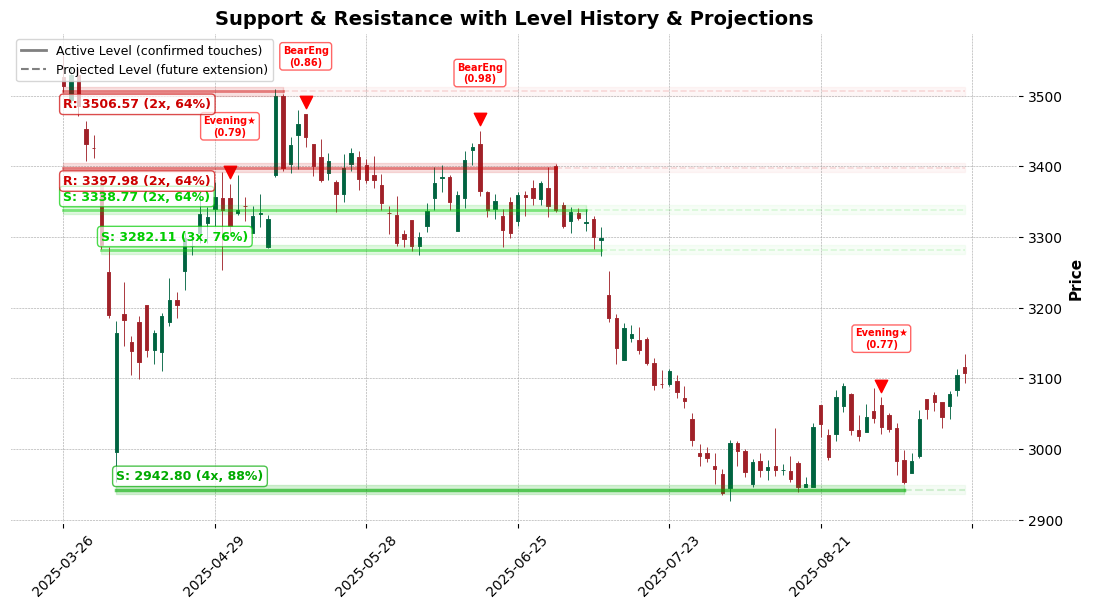

In [6]:
_fig, _axlist = plot_valid_signals(
    candle_df, conf_threshold=0.5, fig=None, axlist=None
)
fig, axlist = plot_support_resistance_enhanced(_df, support, resistance, fig=_fig, axlist=_axlist)
